In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)

In [12]:

DATA_PATH    = r"C:\Users\kaija\Downloads\Task 3 and 4_Loan_Data.csv"
RECOVERY_RATE = 0.10
LGD           = 1 - RECOVERY_RATE   # Loss Given Default = 90%

RISK_HIGH   = 0.70
RISK_MEDIUM = 0.40

FEATURES = [
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score",
    # Engineered
    "debt_to_income",
    "loan_to_income",
    "credit_utilisation",
]

In [13]:
def load_and_engineer(path=DATA_PATH):
    df = pd.read_csv(path)
    df = df.drop(columns=["customer_id"])

    # Engineered ratios — key signals for default risk
    df["debt_to_income"]    = df["total_debt_outstanding"] / df["income"].replace(0, np.nan)
    df["loan_to_income"]    = df["loan_amt_outstanding"]   / df["income"].replace(0, np.nan)
    df["credit_utilisation"]= df["credit_lines_outstanding"] / 5.0   # max observed = 5

    df = df.dropna()
    return df

In [14]:
def train_model(df):
    X = df[FEATURES]
    y = df["default"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    return model, X_train, X_test, y_train, y_test

In [15]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")

    print("=" * 52)
    print("  Model Evaluation — Random Forest")
    print("=" * 52)
    print(f"  ROC-AUC (test set)  : {auc:.4f}")
    print(f"  ROC-AUC (5-fold CV) : {cv.mean():.4f} +/- {cv.std():.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

    return y_prob, auc

In [16]:
def plot_results(model, X_test, y_test, y_prob, df):
    fig = plt.figure(figsize=(16, 14))
    fig.suptitle("Loan Default Prediction Model — Analysis", fontsize=15, fontweight="bold", y=0.98)
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel 1: Feature Importance ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors = ["#e84118" if i >= len(importances) - 3 else "#2e86de" for i in range(len(importances))]
    bars = ax1.barh(importances.index, importances.values, color=colors, edgecolor="white")
    ax1.set_title("Feature Importance (Mean Decrease in Impurity)", fontsize=12)
    ax1.set_xlabel("Importance Score")
    for bar, val in zip(bars, importances.values):
        ax1.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)
    ax1.axvline(0, color="black", linewidth=0.5)

    # ── Panel 2: ROC Curve ───────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax2.plot(fpr, tpr, color="#2e86de", linewidth=2, label=f"AUC = {auc:.4f}")
    ax2.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random classifier")
    ax2.set_title("ROC Curve", fontsize=12)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # ── Panel 3: Confusion Matrix ─────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
    disp.plot(ax=ax3, colorbar=False, cmap="Blues")
    ax3.set_title("Confusion Matrix (threshold = 0.50)", fontsize=12)

    # ── Panel 4: PD Distribution by Actual Outcome ───────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    pd_default    = y_prob[y_test == 1]
    pd_no_default = y_prob[y_test == 0]
    ax4.hist(pd_no_default, bins=40, alpha=0.6, color="#2e86de", label="No Default", density=True)
    ax4.hist(pd_default,    bins=40, alpha=0.6, color="#e84118", label="Default",    density=True)
    ax4.axvline(RISK_HIGH,   color="red",    linestyle="--", linewidth=1.5, label=f"High risk ({RISK_HIGH})")
    ax4.axvline(RISK_MEDIUM, color="orange", linestyle="--", linewidth=1.5, label=f"Medium risk ({RISK_MEDIUM})")
    ax4.set_title("Predicted PD Distribution by Actual Outcome", fontsize=12)
    ax4.set_xlabel("Predicted Probability of Default")
    ax4.set_ylabel("Density")
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)

    # ── Panel 5: Risk Flag Distribution ──────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    all_probs = model.predict_proba(X_test)[:, 1]
    flags = pd.cut(
        all_probs,
        bins=[-np.inf, RISK_MEDIUM, RISK_HIGH, np.inf],
        labels=["LOW", "MEDIUM", "HIGH"]
    ).value_counts().reindex(["LOW", "MEDIUM", "HIGH"])
    bar_colors = ["#27ae60", "#f39c12", "#e84118"]
    bars2 = ax5.bar(flags.index, flags.values, color=bar_colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars2, flags.values):
        ax5.text(bar.get_x() + bar.get_width() / 2, val + 2, str(val),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax5.set_title("Risk Flag Distribution (Test Set)", fontsize=12)
    ax5.set_ylabel("Number of Borrowers")
    ax5.grid(axis="y", alpha=0.3)

    out = r"C:\Users\kaija\quant research\loan_model_analysis.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to: {out}")

In [17]:
_model = None

def _get_model():
    global _model
    if _model is None:
        df = load_and_engineer()
        _model, *_ = train_model(df)
    return _model

In [18]:
def risk_flag(pd_value):
    if pd_value >= RISK_HIGH:
        return "HIGH"
    elif pd_value >= RISK_MEDIUM:
        return "MEDIUM"
    return "LOW"

In [19]:
def expected_loss(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score,
    verbose=True,
):
    """
    Estimate the expected loss on a loan.

    Parameters
    ----------
    credit_lines_outstanding : int   — number of open credit lines
    loan_amt_outstanding     : float — current loan balance ($)
    total_debt_outstanding   : float — total debt across all obligations ($)
    income                   : float — annual income ($)
    years_employed           : int   — years at current employer
    fico_score               : int   — FICO credit score (300-850)

    Returns
    -------
    dict:
        pd_score       — probability of default (0-1)
        expected_loss  — EL in dollars  (PD x LGD x loan_amt_outstanding)
        risk_flag      — "LOW" / "MEDIUM" / "HIGH"
        lgd            — loss given default used (0.90)
    """
    model = _get_model()

    debt_to_income     = total_debt_outstanding / income if income > 0 else np.nan
    loan_to_income     = loan_amt_outstanding   / income if income > 0 else np.nan
    credit_utilisation = credit_lines_outstanding / 5.0

    X = pd.DataFrame([{
        "credit_lines_outstanding": credit_lines_outstanding,
        "loan_amt_outstanding":     loan_amt_outstanding,
        "total_debt_outstanding":   total_debt_outstanding,
        "income":                   income,
        "years_employed":           years_employed,
        "fico_score":               fico_score,
        "debt_to_income":           debt_to_income,
        "loan_to_income":           loan_to_income,
        "credit_utilisation":       credit_utilisation,
    }])

    pd_score = float(model.predict_proba(X)[0, 1])
    el       = pd_score * LGD * loan_amt_outstanding
    flag     = risk_flag(pd_score)

    if verbose:
        print(f"  PD Score       : {pd_score:.4f}  ({pd_score*100:.1f}%)")
        print(f"  LGD            : {LGD:.0%}")
        print(f"  Loan Amount    : ${loan_amt_outstanding:,.2f}")
        print(f"  Expected Loss  : ${el:,.2f}")
        print(f"  Risk Flag      : {flag}")

    return {
        "pd_score":      round(pd_score, 6),
        "expected_loss": round(el, 2),
        "risk_flag":     flag,
        "lgd":           LGD,
    }


Loading data and engineering features...
  Dataset: 10,000 borrowers | Default rate: 18.5%

Training Random Forest model...
  Model Evaluation — Random Forest
  ROC-AUC (test set)  : 0.9997
  ROC-AUC (5-fold CV) : 0.9996 +/- 0.0001

              precision    recall  f1-score   support

  No Default       1.00      0.99      0.99      1630
     Default       0.96      0.99      0.97       370

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.98      2000
weighted avg       0.99      0.99      0.99      2000


Generating analysis plots...


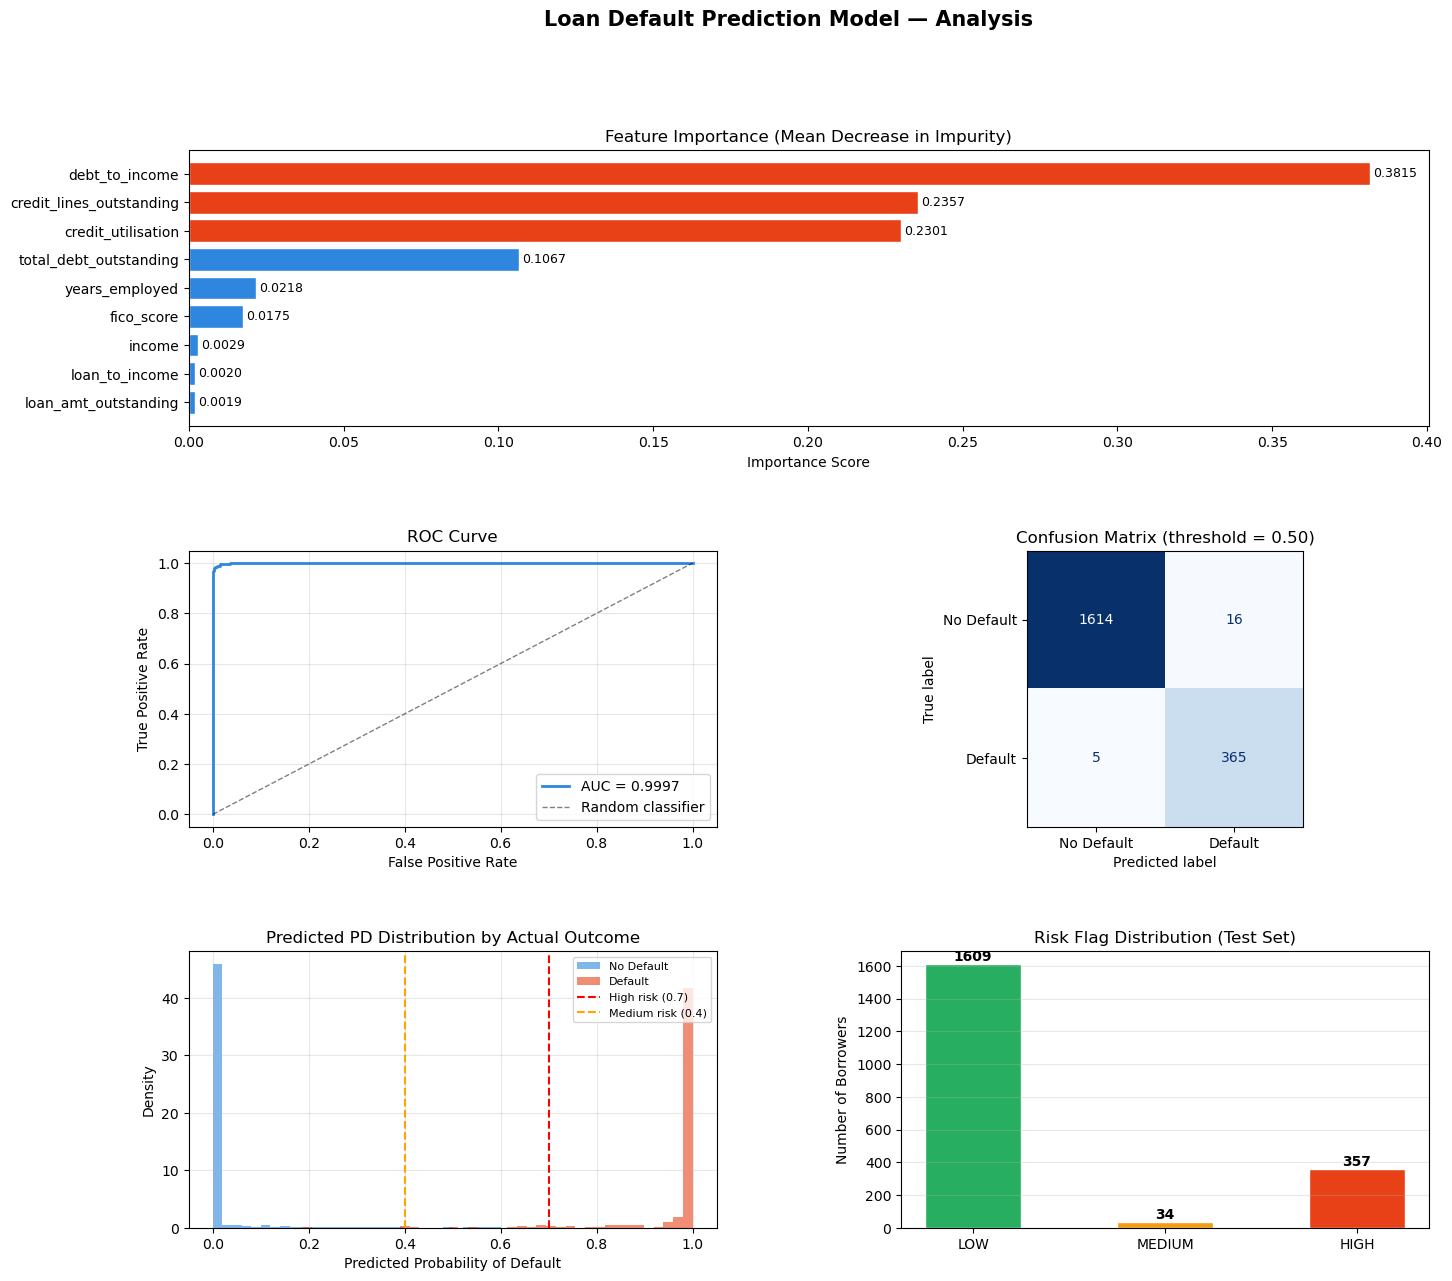

Plot saved to: C:\Users\kaija\quant research\loan_model_analysis.png

  SAMPLE LOAN PREDICTIONS

  >> Low-risk borrower (high income, good FICO)
  PD Score       : 0.0000  (0.0%)
  LGD            : 90%
  Loan Amount    : $5,000.00
  Expected Loss  : $0.00
  Risk Flag      : LOW

  >> Medium-risk borrower (moderate debt, average FICO)
  PD Score       : 0.5751  (57.5%)
  LGD            : 90%
  Loan Amount    : $8,000.00
  Expected Loss  : $4,140.78
  Risk Flag      : MEDIUM

  >> High-risk borrower (heavy debt, low FICO, many credit lines)
  PD Score       : 1.0000  (100.0%)
  LGD            : 90%
  Loan Amount    : $4,500.00
  Expected Loss  : $4,050.00
  Risk Flag      : HIGH

  >> Edge case: high income but very high debt load
  PD Score       : 0.5219  (52.2%)
  LGD            : 90%
  Loan Amount    : $15,000.00
  Expected Loss  : $7,046.16
  Risk Flag      : MEDIUM


In [20]:
if __name__ == "__main__":
    print("Loading data and engineering features...")
    df = load_and_engineer()
    print(f"  Dataset: {len(df):,} borrowers | Default rate: {df['default'].mean():.1%}\n")

    print("Training Random Forest model...")
    model, X_train, X_test, y_train, y_test = train_model(df)
    _model = model

    y_prob, auc = evaluate_model(model, X_train, y_train, X_test, y_test)

    print("\nGenerating analysis plots...")
    plot_results(model, X_test, y_test, y_prob, df)

    print("\n" + "=" * 52)
    print("  SAMPLE LOAN PREDICTIONS")
    print("=" * 52)

    samples = [
        {
            "label": "Low-risk borrower (high income, good FICO)",
            "params": dict(credit_lines_outstanding=0, loan_amt_outstanding=5000,
                           total_debt_outstanding=2000, income=90000,
                           years_employed=7, fico_score=750),
        },
        {
            "label": "Medium-risk borrower (moderate debt, average FICO)",
            "params": dict(credit_lines_outstanding=2, loan_amt_outstanding=8000,
                           total_debt_outstanding=12000, income=45000,
                           years_employed=3, fico_score=600),
        },
        {
            "label": "High-risk borrower (heavy debt, low FICO, many credit lines)",
            "params": dict(credit_lines_outstanding=5, loan_amt_outstanding=4500,
                           total_debt_outstanding=18000, income=27000,
                           years_employed=1, fico_score=480),
        },
        {
            "label": "Edge case: high income but very high debt load",
            "params": dict(credit_lines_outstanding=3, loan_amt_outstanding=15000,
                           total_debt_outstanding=60000, income=120000,
                           years_employed=5, fico_score=640),
        },
    ]

    for s in samples:
        print(f"\n  >> {s['label']}")
        expected_loss(**s["params"])